In [30]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [31]:
# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [32]:
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [33]:
# 3. Train logistic regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [34]:
# 4. Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

In [35]:
# 5. Define thresholds
thresholds = np.linspace(0, 1, 10)

In [37]:
# 6. Compute all metrics
results = []
for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # same as sensitivity / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0

    results.append([
        round(thresh, 2), tp, fp, fn, tn,
        round(accuracy, 2), round(precision, 2), round(recall, 2),
        round(specificity, 2), round(fpr, 2), round(fnr, 2)
    ])

# Convert to dataframe
roc_table = pd.DataFrame(results, columns=[
    "Threshold", "TP", "FP", "FN", "TN",
    "Accuracy", "Precision", "Recall(Sensitivity/TPR)",
    "Specificity", "FPR", "FNR"
])

roc_table

,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall(Sensitivity/TPR),Specificity,FPR,FNR
0,0.00,107,64,0,0,0.63,0.63,1.00,0.00,1.00,0.00
1,0.11,107,11,0,53,0.94,0.91,1.00,0.83,0.17,0.00
2,0.22,107,8,0,56,0.95,0.93,1.00,0.88,0.12,0.00
3,0.33,106,8,1,56,0.95,0.93,0.99,0.88,0.12,0.01
4,0.44,106,7,1,57,0.95,0.94,0.99,0.89,0.11,0.01
5,0.56,105,6,2,58,0.95,0.95,0.98,0.91,0.09,0.02
6,0.67,103,5,4,59,0.95,0.95,0.96,0.92,0.08,0.04
7,0.78,103,4,4,60,0.95,0.96,0.96,0.94,0.06,0.04
8,0.89,95,2,12,62,0.92,0.98,0.89,0.97,0.03,0.11
9,1.00,0,0,107,64,0.37,0.00,0.00,1.00,0.00,1.00


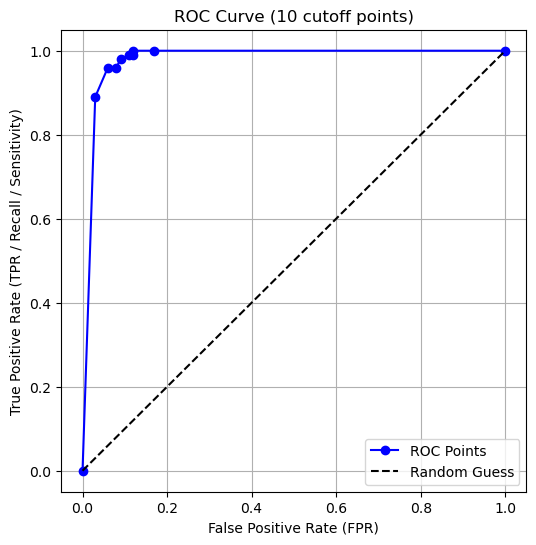

In [38]:
# 7. Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(roc_table["FPR"], roc_table["Recall(Sensitivity/TPR)"],
         marker='o', linestyle='-', color='b', label="ROC Points")
plt.plot([0,1],[0,1],'k--', label="Random Guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall / Sensitivity)")
plt.title("ROC Curve (10 cutoff points)")
plt.legend()
plt.grid(True)
plt.show()